# CIFAR-100 pooling–attention hybrid

Experimental synthesis of PoolFormer.pdf and MetaFormer.pdf; accuracy is unmeasured. Native 32px maps: 32×32×64 (2 pooling blocks), 16×16×128 (2 pooling blocks), 8×8×256 (6 attention blocks), 4×4×384 (2 attention blocks). StarReLU channel MLPs expand by 4; late ResScale multiplies skip paths, initialized to one. No LayerScale or pretrained weights. Stochastic depth peaks at 0.1. Final global average → LayerNorm → MLP classifier.

Select two T4 GPUs and attach CIFAR-100 Python data. Run cells in order. All code is embedded; no additional repository is needed. Validation has 50 images per class (5,000 total), leaving 45,000 for training. Test evaluation is opt-in after settings are frozen.


In [3]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Visible GPUs:", torch.cuda.device_count())
for index in range(torch.cuda.device_count()):
    print(f"GPU {index}: {torch.cuda.get_device_name(index)}")
if torch.cuda.device_count() < 2:
    raise RuntimeError("Select a two-GPU accelerator in Kaggle notebook settings, then restart the session.")


PyTorch: 2.14.1+cu130
CUDA available: True
Visible GPUs: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


## Configuration

Defaults: 300 epochs, AdamW, global batch 256, peak LR 0.0005, five warmup epochs, cosine decay, crop/flip/AutoAugment, MixUp/CutMix, erasing and label smoothing. This is a starting recipe, not a measured optimum. Lower the batch size if necessary before starting.

For resume, attach last.pt and best.pt together and set RESUME to last.pt. Saved settings are restored; continue on two GPUs. Each launch writes into a new writable directory and preserves the previous best. Download checkpoints before ending a session. Resume occurs at epoch boundaries; worker augmentation randomness prevents a guarantee of bitwise equivalence to uninterrupted training.


In [4]:
from datetime import datetime, timezone
from pathlib import Path

DATASET = "cifar100"
DATA_ROOT = "/kaggle/input/datasets/nhatxminh2603/cifar-100-python"
VARIANT = "hybrid"
EPOCHS = 300
WARMUP_EPOCHS = 5
BATCH_SIZE_PER_GPU = 128
IMAGE_SIZE = 32
WORKERS_PER_GPU = 2
LEARNING_RATE = 5e-4
SEED = 42
SPLIT_SEED = 42
SMOKE_TEST = False
DOWNLOAD = False
RESUME = None  # path to previous last.pt; keep best.pt alongside it

if RESUME:
    saved = torch.load(RESUME, map_location="cpu", weights_only=True)["config"]
    if saved["variant"] != "hybrid":
        raise ValueError("Choose a hybrid checkpoint")
    EPOCHS, WARMUP_EPOCHS = saved["epochs"], saved["warmup_epochs"]
    BATCH_SIZE_PER_GPU, LEARNING_RATE = saved["batch_size"], saved["lr"]
    SEED, SPLIT_SEED, SMOKE_TEST = saved["seed"], saved["split_seed"], saved["smoke_test"]
WORKING = Path("/kaggle/working")
WORKING.mkdir(parents=True, exist_ok=True)


In [5]:
%%writefile /kaggle/working/poolformer.py
import torch
import torch.nn as nn
from torchvision.ops import StochasticDepth

# PoolFormer.pdf, Tables 1 and 6: depths, widths, peak drop rate, LayerScale.
VARIANTS = {
    "s12": ((2, 2, 6, 2), (64, 128, 320, 512), 0.1, 1e-5),
    "s24": ((4, 4, 12, 4), (64, 128, 320, 512), 0.1, 1e-5),
    "s36": ((6, 6, 18, 6), (64, 128, 320, 512), 0.2, 1e-6),
    "m36": ((6, 6, 18, 6), (96, 192, 384, 768), 0.3, 1e-6),
    "m48": ((8, 8, 24, 8), (96, 192, 384, 768), 0.4, 1e-6),
}

class StarReLU(nn.Module):
    def __init__(self, scale: float = 1.0, bias: float = 0.0):
        super().__init__()
        self.s = nn.Parameter(torch.tensor(scale))
        self.b = nn.Parameter(torch.tensor(bias))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.s * torch.relu(x).square() + self.b

class PoolFormerBlock(nn.Module):
    def __init__(self, dim: int, pool_size: int = 3, mlp_ratio: float = 4.0, act_layer=nn.GELU, ls_init: float = 1e-5, drop_path: float = 0.0):
        super().__init__()
        if pool_size < 1 or pool_size % 2 == 0:
            raise ValueError("pool_size must be a positive odd integer")
        self.norm1 = nn.GroupNorm(1, dim)
        self.pool = nn.AvgPool2d(pool_size, stride=1, padding=pool_size // 2, count_include_pad=False)
        self.norm2 = nn.GroupNorm(1, dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Conv2d(dim, hidden, 1),
            act_layer(),
            nn.Conv2d(hidden, dim, 1),
        )
        self.s1 = nn.Parameter(ls_init * torch.ones(dim, 1, 1))
        self.s2 = nn.Parameter(ls_init * torch.ones(dim, 1, 1))
        self.drop_path = StochasticDepth(drop_path, mode="row")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        normalized = self.norm1(x)
        x = x + self.drop_path(self.s1 * (self.pool(normalized) - normalized))
        x = x + self.drop_path(self.s2 * self.mlp(self.norm2(x)))
        return x

class PoolFormer(nn.Module):
    def __init__(self, layers=(2, 2, 6, 2), dims=(64, 128, 320, 512), num_classes=1000, act_layer=nn.GELU, drop_path_rate=0.1, ls_init=1e-5):
        super().__init__()
        if len(layers) != 4 or len(dims) != 4 or any(n < 1 for n in (*layers, *dims)):
            raise ValueError("layers and dims must each contain four positive integers")
        if num_classes < 1 or not 0 <= drop_path_rate < 1:
            raise ValueError("num_classes must be positive and drop_path_rate must be in [0, 1)")
        self.stages = nn.ModuleList()
        in_c = 3
        patch_specs = [(7, 4, 2), (3, 2, 1), (3, 2, 1), (3, 2, 1)]
        block_index = 0
        for (k, s, p), d, num_b in zip(patch_specs, dims, layers):
            stage = [nn.Conv2d(in_c, d, kernel_size=k, stride=s, padding=p)]
            stage += [PoolFormerBlock(
                d, act_layer=act_layer, ls_init=ls_init,
                drop_path=drop_path_rate * (block_index + i) / max(sum(layers) - 1, 1),
            ) for i in range(num_b)]
            self.stages.append(nn.Sequential(*stage))
            in_c = d
            block_index += num_b
        self.norm = nn.GroupNorm(1, dims[-1])
        self.head = nn.Linear(dims[-1], num_classes)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            nn.init.trunc_normal_(module.weight, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for stage in self.stages:
            x = stage(x)
        return self.head(self.norm(x).mean(dim=[-2, -1]))

# Standard variants: S12, S24, S36, M36, M48
def create_poolformer(variant="s12", num_classes=1000):
    layers, dims, drop_rate, ls_init = VARIANTS[variant]
    return PoolFormer(layers, dims, num_classes, drop_path_rate=drop_rate, ls_init=ls_init)


def poolformer_s12(num_classes=1000): return create_poolformer("s12", num_classes)
def poolformer_s24(num_classes=1000): return create_poolformer("s24", num_classes)
def poolformer_s36(num_classes=1000): return create_poolformer("s36", num_classes)
def poolformer_m36(num_classes=1000): return create_poolformer("m36", num_classes)
def poolformer_m48(num_classes=1000): return create_poolformer("m48", num_classes)

if __name__ == "__main__":
    m = poolformer_s12()
    out = m(torch.randn(2, 3, 224, 224))
    assert out.shape == (2, 1000)
    print(f"PoolFormer-S12 OK: {sum(p.numel() for p in m.parameters()) / 1e6:.1f}M params")


Overwriting /kaggle/working/poolformer.py


In [6]:
%%writefile /kaggle/working/hybridformer.py
"""Experimental CIFAR hybrid: PoolFormer mixing + MetaFormer attention/blocks."""
import torch
from torch import nn
from torch.nn import functional as F
from torchvision.ops import StochasticDepth

from poolformer import PoolFormer, StarReLU


class ChannelNorm(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        return F.layer_norm(x.permute(0, 2, 3, 1), self.weight.shape,
                            self.weight, eps=1e-6).permute(0, 3, 1, 2)


class Attention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.heads = dim // 64
        self.qkv = nn.Linear(dim, 3 * dim, bias=False)
        self.proj = nn.Linear(dim, dim, bias=False)

    def forward(self, x):
        b, c, h, w = x.shape
        tokens = x.flatten(2).transpose(1, 2)
        q, k, v = self.qkv(tokens).reshape(b, h * w, 3, self.heads, 64).permute(2, 0, 3, 1, 4).unbind(0)
        tokens = F.scaled_dot_product_attention(q, k, v).transpose(1, 2).reshape(b, h * w, c)
        return self.proj(tokens).transpose(1, 2).reshape(b, c, h, w)


class HybridBlock(nn.Module):
    def __init__(self, dim, attention=False, drop_path=0.0):
        super().__init__()
        if attention:
            self.norm1, self.norm2 = ChannelNorm(dim), ChannelNorm(dim)
            self.mixer = Attention(dim)
            # MetaFormer Eq. 17 scales the skip path, initialized to one.
            self.r1 = nn.Parameter(torch.ones(dim, 1, 1))
            self.r2 = nn.Parameter(torch.ones(dim, 1, 1))
        else:
            self.norm1, self.norm2 = nn.GroupNorm(1, dim), nn.GroupNorm(1, dim)
            self.norm1.register_parameter("bias", None)
            self.norm2.register_parameter("bias", None)
            self.mixer = nn.AvgPool2d(3, stride=1, padding=1, count_include_pad=False)
            self.register_buffer("r1", torch.tensor(1.0))
            self.register_buffer("r2", torch.tensor(1.0))
        self.attention = attention
        self.mlp = nn.Sequential(nn.Conv2d(dim, 4 * dim, 1, bias=False),
                                 StarReLU(), nn.Conv2d(4 * dim, dim, 1, bias=False))
        self.drop_path = StochasticDepth(drop_path, mode="row")

    def forward(self, x):
        normalized = self.norm1(x)
        mixed = self.mixer(normalized)
        if not self.attention:
            mixed = mixed - normalized
        x = self.r1 * x + self.drop_path(mixed)
        return self.r2 * x + self.drop_path(self.mlp(self.norm2(x)))


class HybridFormer(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        if num_classes < 1:
            raise ValueError("num_classes must be positive")
        depths, dims = (2, 2, 6, 2), (64, 128, 256, 384)
        self.stages = nn.ModuleList()
        in_channels, block_index = 3, 0
        for stage_index, (depth, dim) in enumerate(zip(depths, dims)):
            stage = [nn.Conv2d(in_channels, dim, 3, stride=1 if stage_index == 0 else 2,
                               padding=1, bias=False)]
            stage += [HybridBlock(dim, attention=stage_index >= 2,
                                  drop_path=0.1 * (block_index + i) / 11) for i in range(depth)]
            self.stages.append(nn.Sequential(*stage))
            in_channels, block_index = dim, block_index + depth
        self.norm = nn.LayerNorm(dims[-1])
        self.head = nn.Sequential(nn.Linear(dims[-1], 4 * dims[-1], bias=False),
                                  StarReLU(), nn.Linear(4 * dims[-1], num_classes))
        self.apply(PoolFormer._init_weights)

    def forward(self, x):
        for stage in self.stages:
            x = stage(x)
        return self.head(self.norm(x.mean(dim=(-2, -1))))


Writing /kaggle/working/hybridformer.py


In [7]:
%%writefile /kaggle/working/train_poolformer.py
"""PoolFormer/HybridFormer training with DDP; see README.md."""
import argparse
import json
import math
import os
import random
import shutil
import time
from pathlib import Path

import torch
import torch.distributed as dist
from torch import nn
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import DataLoader, Subset
from torch.utils.data.distributed import DistributedSampler
from torchvision import datasets, transforms
from torchvision.transforms import v2
from tqdm.auto import tqdm

from poolformer import VARIANTS, create_poolformer


def stratified_split(targets, seed):
    generator = torch.Generator().manual_seed(seed)
    labels = torch.tensor(targets)
    train, val = [], []
    for label in labels.unique(sorted=True):
        indices = torch.where(labels == label)[0]
        indices = indices[torch.randperm(len(indices), generator=generator)].tolist()
        count = len(indices) // 10
        val.extend(indices[:count])
        train.extend(indices[count:])
    return train, val


def create_model(variant, num_classes):
    if variant == "hybrid":
        from hybridformer import HybridFormer
        return HybridFormer(num_classes)
    return create_poolformer(variant, num_classes)


def make_datasets(args):
    cifar = args.dataset == "cifar100"
    mean = (0.5071, 0.4867, 0.4408) if cifar else (0.485, 0.456, 0.406)
    std = (0.2675, 0.2565, 0.2761) if cifar else (0.229, 0.224, 0.225)
    policy = transforms.AutoAugmentPolicy.CIFAR10 if cifar else transforms.AutoAugmentPolicy.IMAGENET
    native_cifar = cifar and args.image_size == 32
    crop = transforms.RandomCrop(32, padding=4) if native_cifar else transforms.RandomResizedCrop(
        args.image_size, interpolation=transforms.InterpolationMode.BICUBIC)
    train_transform = transforms.Compose([
        crop,
        transforms.RandomHorizontalFlip(), transforms.AutoAugment(policy),
        transforms.ToTensor(), transforms.Normalize(mean, std),
        transforms.RandomErasing(p=0.25),
    ])
    val_transform = transforms.Compose(([] if native_cifar else [
        transforms.Resize(round(args.image_size / 0.875), interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.CenterCrop(args.image_size)]) + [transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    if args.smoke_test:
        return (datasets.FakeData(4, (3, args.image_size, args.image_size), 100, train_transform),
                datasets.FakeData(5, (3, args.image_size, args.image_size), 100, val_transform, random_offset=4),
                None)
    if cifar:
        root = Path(args.data)
        if root.name == "cifar-100-python" and (root / "train").exists():
            args.data = str(root.parent)
        train = datasets.CIFAR100(args.data, train=True, download=args.download, transform=train_transform)
        val = datasets.CIFAR100(args.data, train=True, transform=val_transform)
        train_indices, val_indices = stratified_split(train.targets, args.split_seed)
        test = datasets.CIFAR100(args.data, train=False, download=args.download, transform=val_transform)
        return Subset(train, train_indices), Subset(val, val_indices), test
    train = datasets.ImageFolder(Path(args.data) / "train", transform=train_transform)
    val = datasets.ImageFolder(Path(args.data) / "val", transform=val_transform)
    if train.class_to_idx != val.class_to_idx:
        raise ValueError("train/ and val/ must have matching class folders")
    return train, val, None


def run_epoch(model, loader, criterion, device, optimizer=None, mixer=None, scaler=None):
    training = optimizer is not None
    model.train(training)
    # Evaluation shards may have unequal lengths; bypass DDP forward collectives.
    forward_model = model.module if not training and isinstance(model, DDP) else model
    rank = dist.get_rank() if dist.is_initialized() else 0
    loss_sum = correct = count = 0
    with torch.set_grad_enabled(training):
        progress = tqdm(loader, desc="Train" if training else "Evaluate", leave=False, disable=rank != 0)
        for images, labels in progress:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            hard_labels = labels
            if training:
                images, labels = mixer(images, labels)
                optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
                logits = forward_model(images)
                loss = criterion(logits, labels)
            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            loss_sum += loss.item() * images.size(0)
            # Accuracy is meaningful on the unaugmented validation data only.
            if not training:
                correct += (logits.argmax(1) == hard_labels).sum().item()
            count += images.size(0)
            if rank == 0:
                metrics = {"loss": f"{loss_sum / count:.4f}"}
                if not training:
                    metrics["accuracy"] = f"{100 * correct / count:.2f}%"
                progress.set_postfix(metrics)
    totals = torch.tensor([loss_sum, correct, count], dtype=torch.float64, device=device)
    if dist.is_initialized():
        dist.all_reduce(totals)
    loss_sum, correct, count = totals.tolist()
    return loss_sum / count, 100 * correct / count


def main(argv=None):
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--dataset", choices=("cifar100", "imagenet"), default="cifar100")
    parser.add_argument("--data", default="data")
    parser.add_argument("--variant", choices=(*VARIANTS, "hybrid"), default="s12")
    parser.add_argument("--epochs", type=int, default=300)
    parser.add_argument("--batch-size", type=int, default=64, help="Batch size per GPU/process")
    parser.add_argument("--image-size", type=int, default=224)
    parser.add_argument("--workers", type=int, default=4)
    parser.add_argument("--warmup-epochs", type=int, default=5)
    parser.add_argument("--lr", type=float, help="Default: 0.001 * global_batch_size / 1024")
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--split-seed", type=int, default=42, help="Fixed stratified CIFAR validation split")
    parser.add_argument("--resume", type=Path, help="Resume last.pt with the same training configuration")
    parser.add_argument("--evaluate-only", action="store_true", help="Evaluate --resume checkpoint on the official test set")
    parser.add_argument("--evaluate-test", action="store_true", help="Evaluate best checkpoint after training; enable only after settings are frozen")
    parser.add_argument("--output", type=Path, default=Path("runs/poolformer"))
    parser.add_argument("--download", action="store_true", help="Download CIFAR-100 if needed")
    parser.add_argument("--smoke-test", action="store_true", help="One epoch on synthetic data at 32px")
    args = parser.parse_args(argv)
    if args.evaluate_only and (args.resume is None or args.dataset != "cifar100" or args.smoke_test):
        parser.error("evaluate-only requires --resume and real CIFAR-100 data")
    if args.variant == "hybrid" and (args.dataset != "cifar100" or args.image_size != 32) and not args.smoke_test:
        parser.error("the hybrid is designed for CIFAR-100 at --image-size 32")
    if args.smoke_test:
        args.epochs, args.batch_size, args.image_size, args.workers, args.warmup_epochs = 1, 2, 32, 0, 0
        torch.set_num_threads(2)
    if min(args.epochs, args.batch_size, args.image_size) < 1 or args.workers < 0:
        parser.error("epochs, batch-size, image-size must be positive; workers must be nonnegative")
    if not 0 <= args.warmup_epochs < args.epochs:
        parser.error("warmup-epochs must be nonnegative and less than epochs")
    if args.lr is not None and (not math.isfinite(args.lr) or args.lr <= 0):
        parser.error("lr must be finite and positive")
    # A new run must not silently replace another run's checkpoints.
    existing_checkpoints = any((args.output / name).exists() for name in ("best.pt", "last.pt"))
    if existing_checkpoints and not args.evaluate_only and (
        args.resume is None or args.output.resolve() != args.resume.parent.resolve()
    ):
        parser.error("output already contains checkpoints; choose a new --output directory")
    resumed = None
    if args.resume is not None:
        resumed = torch.load(args.resume, map_location="cpu", weights_only=True)
        if not args.evaluate_only:
            for key in ("variant", "dataset", "image_size", "epochs", "warmup_epochs", "batch_size", "lr", "seed", "split_seed", "smoke_test"):
                if resumed["config"].get(key) != getattr(args, key):
                    parser.error(f"resume requires the original {key}={resumed['config'].get(key)!r}")
            if args.resume.name != "last.pt":
                parser.error("resume training from last.pt; use best.pt with --evaluate-only")
        elif resumed["variant"] != args.variant or resumed["num_classes"] != 100:
            parser.error("checkpoint architecture must match --variant and CIFAR-100")
    distributed = int(os.environ.get("WORLD_SIZE", "1")) > 1
    local_rank = int(os.environ.get("LOCAL_RANK", "0"))
    if torch.cuda.is_available():
        torch.cuda.set_device(local_rank)
        device = torch.device("cuda", local_rank)
    else:
        device = torch.device("cpu")
    if distributed:
        dist.init_process_group("nccl" if device.type == "cuda" else "gloo")
    rank = dist.get_rank() if distributed else 0
    world_size = dist.get_world_size() if distributed else 1
    random.seed(args.seed + rank)
    torch.manual_seed(args.seed + rank)
    if distributed and args.download and args.dataset == "cifar100" and not args.smoke_test:
        if rank == 0:
            datasets.CIFAR100(args.data, train=True, download=True)
        dist.barrier()
        args.download = False
    train, val, test = make_datasets(args)
    num_classes = 100 if args.dataset == "cifar100" or args.smoke_test else len(train.classes)
    loader_args = dict(batch_size=args.batch_size, num_workers=args.workers,
                       pin_memory=device.type == "cuda", persistent_workers=args.workers > 0)
    train_sampler = DistributedSampler(train, seed=args.seed) if distributed else None
    train_loader = DataLoader(train, shuffle=train_sampler is None, sampler=train_sampler, **loader_args)
    # Disjoint evaluation shards, with no padding/duplicate samples.
    if distributed:
        val = Subset(val, range(rank, len(val), world_size))
    val_loader = DataLoader(val, **loader_args)
    model = create_model(args.variant, num_classes).to(device)
    if resumed is not None:
        model.load_state_dict(resumed["model"])
    if distributed:
        model = DDP(model, device_ids=[local_rank] if device.type == "cuda" else None)
    base_model = model.module if distributed else model
    # Bias, normalization and branch scaling receive no decay.
    scale_names = ("s1", "s2", "r1", "r2")
    decay = [p for name, p in base_model.named_parameters() if p.ndim > 1 and not name.endswith(scale_names)]
    no_decay = [p for name, p in base_model.named_parameters() if p.ndim <= 1 or name.endswith(scale_names)]
    lr = args.lr if args.lr is not None else 1e-3 * args.batch_size * world_size / 1024
    optimizer = torch.optim.AdamW([
        {"params": decay, "weight_decay": 0.05},
        {"params": no_decay, "weight_decay": 0.0},
    ], lr=lr)

    def lr_factor(epoch):
        if epoch < args.warmup_epochs:
            return (epoch + 1) / args.warmup_epochs
        progress = (epoch - args.warmup_epochs) / (args.epochs - args.warmup_epochs)
        return 0.5 * (1 + math.cos(math.pi * min(progress, 1)))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_factor)
    scaler = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")
    mixer = v2.RandomChoice([v2.MixUp(alpha=0.8, num_classes=num_classes),
                             v2.CutMix(alpha=1.0, num_classes=num_classes)])
    train_loss = nn.CrossEntropyLoss(label_smoothing=0.1)
    val_loss = nn.CrossEntropyLoss()
    if rank == 0 and not args.evaluate_only:
        args.output.mkdir(parents=True, exist_ok=True)
    best_acc = -1.0
    start_epoch, best_epoch, training_seconds = 0, 0, 0.0
    parameter_count = sum(p.numel() for p in base_model.parameters())
    if resumed is not None and not args.evaluate_only:
        if resumed["world_size"] != world_size:
            raise ValueError("Resume with the original number of processes/GPUs")
        optimizer.load_state_dict(resumed["optimizer"])
        scheduler.load_state_dict(resumed["scheduler"])
        scaler.load_state_dict(resumed["scaler"])
        start_epoch, best_acc = resumed["epoch"], resumed["best_accuracy"]
        best_epoch = resumed.get("best_epoch", 0)
        training_seconds = resumed.get("training_seconds", 0.0)
        rng = resumed["rng_states"][rank]
        random.setstate(rng["python"])
        torch.set_rng_state(rng["torch"])
        if device.type == "cuda":
            torch.cuda.set_rng_state(rng["cuda"], device)
        # Preserve the earlier best even when resuming into a writable new directory.
        # Recover an improved last.pt if interruption happened before writing best.pt.
        source_best = args.resume if start_epoch == best_epoch else args.resume.parent / "best.pt"
        if not source_best.exists():
            raise ValueError("Resume requires best.pt alongside last.pt")
        if rank == 0 and source_best.resolve() != (args.output / "best.pt").resolve():
            shutil.copy2(source_best, args.output / "best.pt")
        if rank == 0 and args.resume.resolve() != (args.output / "last.pt").resolve():
            shutil.copy2(args.resume, args.output / "last.pt")
    if args.evaluate_only:
        if distributed:
            test = Subset(test, range(rank, len(test), world_size))
        test_loss, test_accuracy = run_epoch(model, DataLoader(test, **loader_args), val_loss, device)
        if rank == 0:
            print(f"Checkpoint CIFAR-100 test loss: {test_loss:.4f} | accuracy: {test_accuracy:.2f}%")
        if distributed:
            dist.destroy_process_group()
        return
    if rank == 0:
        print(f"{args.variant.upper()} | {device} | world size={world_size} | "
              f"global batch={args.batch_size * world_size} | "
              f"{sum(p.numel() for p in model.parameters()) / 1e6:.2f}M parameters | peak lr={lr:g}")
    for epoch in range(start_epoch, args.epochs):
        if train_sampler is not None:
            train_sampler.set_epoch(epoch)
        if device.type == "cuda":
            torch.cuda.synchronize(device)
            torch.cuda.reset_peak_memory_stats(device)
        epoch_start = time.perf_counter()
        current_lr = optimizer.param_groups[0]["lr"]
        loss, _ = run_epoch(model, train_loader, train_loss, device, optimizer, mixer, scaler)
        eval_loss, accuracy = run_epoch(model, val_loader, val_loss, device)
        if device.type == "cuda":
            torch.cuda.synchronize(device)
        performance = torch.tensor([time.perf_counter() - epoch_start,
                                    torch.cuda.max_memory_allocated(device) if device.type == "cuda" else 0],
                                   dtype=torch.float64, device=device)
        if distributed:
            dist.all_reduce(performance, op=dist.ReduceOp.MAX)
        seconds, peak_memory = performance.tolist()
        training_seconds += seconds
        scheduler.step()
        improved = accuracy > best_acc
        if improved:
            best_epoch = epoch + 1
        best_acc = max(best_acc, accuracy)
        rng = dict(python=random.getstate(), torch=torch.get_rng_state(),
                   cuda=torch.cuda.get_rng_state(device) if device.type == "cuda" else None)
        rng_states = [None] * world_size
        if distributed:
            dist.all_gather_object(rng_states, rng)
        else:
            rng_states[0] = rng
        if rank == 0:
            checkpoint = dict(model=base_model.state_dict(), optimizer=optimizer.state_dict(),
                              scheduler=scheduler.state_dict(), scaler=scaler.state_dict(),
                              epoch=epoch + 1, best_epoch=best_epoch, best_accuracy=best_acc,
                              val_loss=eval_loss, val_accuracy=accuracy, variant=args.variant,
                              num_classes=num_classes, world_size=world_size,
                              training_seconds=training_seconds, rng_states=rng_states,
                              config={**vars(args), "output": str(args.output),
                                      "resume": str(args.resume) if args.resume is not None else None})
            for name in (["last.pt", "best.pt"] if improved else ["last.pt"]):
                temporary = args.output / (name + ".tmp")
                torch.save(checkpoint, temporary)
                temporary.replace(args.output / name)
            metrics = dict(epoch=epoch + 1, lr=current_lr, train_loss=loss, val_loss=eval_loss,
                           val_accuracy=accuracy, best_accuracy=best_acc, seconds=seconds,
                           peak_gpu_memory_mib=peak_memory / 2**20, parameters=parameter_count,
                           training_seconds=training_seconds)
            with (args.output / "metrics.jsonl").open("a") as log:
                log.write(json.dumps(metrics) + "\n")
            print(f"Epoch {epoch + 1}/{args.epochs} | lr={current_lr:g} | train loss={loss:.4f} | "
                  f"val loss={eval_loss:.4f} | val accuracy={accuracy:.2f}% | "
                  f"{seconds:.1f}s | peak GPU memory={peak_memory / 2**20:.0f} MiB", flush=True)
        if distributed:
            dist.barrier()
    test_accuracy = None
    if test is not None and args.evaluate_test:
        checkpoint = torch.load(args.output / "best.pt", map_location=device, weights_only=True)
        base_model.load_state_dict(checkpoint["model"])
        if distributed:
            test = Subset(test, range(rank, len(test), world_size))
        _, accuracy = run_epoch(model, DataLoader(test, **loader_args), val_loss, device)
        test_accuracy = accuracy
        if rank == 0:
            print(f"Best checkpoint CIFAR-100 test accuracy: {accuracy:.2f}%")
    if rank == 0:
        summary = dict(variant=args.variant, parameters=parameter_count, best_val_accuracy=best_acc,
                       training_seconds=training_seconds, completed_epochs=args.epochs,
                       test_accuracy=test_accuracy)
        (args.output / "summary.json").write_text(json.dumps(summary, indent=2) + "\n")
        print(f"Best validation accuracy: {best_acc:.2f}% | checkpoints: {args.output}")
    if distributed:
        dist.destroy_process_group()


if __name__ == "__main__":
    try:
        main()
    finally:
        if dist.is_initialized():
            dist.destroy_process_group()


Overwriting /kaggle/working/train_poolformer.py


## Launch

Rank zero shows progress; epoch metrics combine both GPUs. Interrupting this cell terminates both workers. Set SMOKE_TEST=True for a one-epoch synthetic launch check.


In [8]:
import codecs
import os
import shlex
import subprocess
import sys

run_id = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S_%f")
OUTPUT = WORKING / ("hybridformer_" + VARIANT + ("_smoke_" if SMOKE_TEST else "_") + run_id)
command = [
    sys.executable, "-u", "-m", "torch.distributed.run",
    "--standalone", "--nproc_per_node=2",
    str(WORKING / "train_poolformer.py"),
    "--dataset", DATASET, "--data", DATA_ROOT, "--variant", VARIANT,
    "--epochs", str(EPOCHS), "--warmup-epochs", str(WARMUP_EPOCHS),
    "--batch-size", str(BATCH_SIZE_PER_GPU), "--image-size", str(IMAGE_SIZE),
    "--workers", str(WORKERS_PER_GPU), "--seed", str(SEED), "--output", str(OUTPUT),
]
command += ["--split-seed", str(SPLIT_SEED)]
if RESUME:
    command += ["--resume", str(RESUME)]
if LEARNING_RATE is not None:
    command += ["--lr", str(LEARNING_RATE)]
if DOWNLOAD:
    command += ["--download"]
if SMOKE_TEST:
    command += ["--smoke-test"]
print(shlex.join(command), flush=True)

# Forward bytes to Jupyter while preserving tqdm carriage returns.
# A separate process group lets Interrupt stop torchrun and both workers.
import signal
process = subprocess.Popen(command, cwd=WORKING, stdout=subprocess.PIPE,
                           stderr=subprocess.STDOUT, start_new_session=True, bufsize=0)
decoder = codecs.getincrementaldecoder("utf-8")(errors="replace")
try:
    while True:
        chunk = os.read(process.stdout.fileno(), 4096)
        if not chunk:
            break
        sys.stdout.write(decoder.decode(chunk))
        sys.stdout.flush()
    sys.stdout.write(decoder.decode(b"", final=True))
    return_code = process.wait()
    if return_code:
        raise subprocess.CalledProcessError(return_code, command)
except BaseException:
    if process.poll() is None:
        os.killpg(process.pid, signal.SIGTERM)
        try:
            process.wait(timeout=10)
        except subprocess.TimeoutExpired:
            os.killpg(process.pid, signal.SIGKILL)
            process.wait()
    raise
finally:
    process.stdout.close()


/usr/bin/python3 -u -m torch.distributed.run --standalone --nproc_per_node=2 /kaggle/working/train_poolformer.py --dataset cifar100 --data /kaggle/input/datasets/nhatxminh2603/cifar-100-python --variant hybrid --epochs 300 --warmup-epochs 5 --batch-size 128 --image-size 32 --workers 2 --seed 42 --output /kaggle/working/hybridformer_hybrid_20261006_042506_718548 --split-seed 42 --lr 0.0005

*****************************************
Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
*****************************************
[W1006 04:25:08.893628210 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
[W1006 04:25:14.320306786 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
[W1006 04:25:14.320761515 socket.cpp:207] [c10d] The hostname of the client socket cannot b

## Checkpoint and performance

best.pt is selected by validation accuracy; last.pt includes optimizer, scheduler, scaler and per-rank RNG state. metrics.jsonl records losses, accuracy, epoch time and maximum allocated memory across GPUs. summary.json reports parameters, best validation accuracy and cumulative train/validation time. Timing excludes checkpoint writes. GPU memory excludes CUDA context and reserved allocator memory; CPU checks report zero.


Best checkpoint: /kaggle/working/hybridformer_hybrid_20261006_042506_718548/best.pt
{
  "variant": "hybrid",
  "parameters": 10594622,
  "best_val_accuracy": 75.7,
  "training_seconds": 9591.364178892005,
  "completed_epochs": 300,
  "test_accuracy": null
}


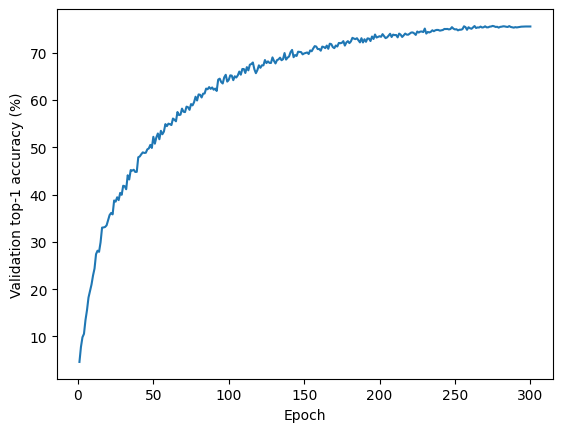

In [9]:
import json
sys.path.insert(0, str(WORKING))
from hybridformer import HybridFormer

checkpoint_path = OUTPUT / "best.pt"
checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=True)
model = HybridFormer(checkpoint["num_classes"])
model.load_state_dict(checkpoint["model"])
model.eval()
print("Best checkpoint:", checkpoint_path)
print(json.dumps(json.loads((OUTPUT / "summary.json").read_text()), indent=2))
if (OUTPUT / "metrics.jsonl").exists():
    history = [json.loads(line) for line in (OUTPUT / "metrics.jsonl").read_text().splitlines()]
    import matplotlib.pyplot as plt
    plt.plot([row["epoch"] for row in history], [row["val_accuracy"] for row in history])
    plt.xlabel("Epoch")
    plt.ylabel("Validation top-1 accuracy (%)")
    plt.show()


## Final test evaluation

Enable RUN_FINAL_TEST only after settings are frozen. Evaluate the best checkpoint without additional training. Do not tune using test results. Smoke checkpoints cannot be used here.


In [11]:
RUN_FINAL_TEST = True
if RUN_FINAL_TEST:
    if SMOKE_TEST:
        raise ValueError("Train on real CIFAR-100 before final evaluation")
    evaluation_command = [
        sys.executable, "-u", "-m", "torch.distributed.run", "--standalone", "--nproc_per_node=2",
        str(WORKING / "train_poolformer.py"), "--variant", "hybrid", "--image-size", "32",
        "--data", DATA_ROOT, "--batch-size", str(BATCH_SIZE_PER_GPU),
        "--workers", str(WORKERS_PER_GPU), "--resume", str(checkpoint_path), "--evaluate-only",
    ]
    subprocess.run(evaluation_command, cwd=WORKING, check=True)



*****************************************
Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
*****************************************
[W1006 07:12:41.171629412 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
[W1006 07:12:45.945760447 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
[W1006 07:12:45.952958872 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3


Checkpoint CIFAR-100 test loss: 1.1412 | accuracy: 75.27%
